# 02 — Calidad de datos

Esta es la notebook que más se mira en una entrevista técnica: no muestra código,
muestra **criterio**.

La regla que sigo: **nunca descarto sin medir el impacto, y nunca elijo entre dos
fuentes sin medir cuánto se contradicen.**

Lo que se documenta acá:

1. Qué descarta cada regla de limpieza y cuánto pesa
2. El campo `productos_ean` que no contiene el EAN
3. Unidades de medida: texto libre mezclado con un estándar internacional
4. Dos fuentes oficiales del tamaño del envase que no coinciden
5. Saltos de precio imposibles
6. Cadenas y sucursales que entran y salen del reporte

In [9]:
import os, sys, warnings
sys.path.insert(0, "..")
# Los datos crudos viven fuera del repo (pesan GB). Si moviste la carpeta,
# cambiá esta ruta o exportá RADAR_DATA_DIR antes de abrir el notebook.
os.environ.setdefault("RADAR_DATA_DIR", os.path.expanduser("~/sepa-data"))
warnings.filterwarnings("ignore")

import duckdb, pandas as pd, matplotlib.pyplot as plt
from src import config as cfg

pd.set_option("display.max_columns", 40); pd.set_option("display.width", 150)
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold"})

PARQUET = str(cfg.INTERIM / "fecha=*" / "*.parquet")
con = duckdb.connect()
dias = sorted(p.name.split("=")[1] for p in cfg.INTERIM.glob("fecha=*"))
assert dias, f"No hay datos en {cfg.INTERIM}. Corré primero: python -m src.clean"
print(f"Datos: {cfg.DATA}")
print(f"{len(dias)} días — de {dias[0]} a {dias[-1]}")

Datos: /Users/juanignaciogarciarios/sepa-data
7 días — de 2026-07-19 a 2026-07-25


## 1. Qué descarta cada regla

`clean.py` deja registro diario de cuánto tiró cada regla. Sin esto, una regla mal
escrita puede comerse el 90% de los datos sin que nadie se entere.

,fecha,filas_crudas,desc_nulos,desc_ean_invalido,desc_precio_fuera_rango,desc_duplicados,desc_outliers,filas_finales,pct_descartado,eans_unicos,sucursales,cadenas,pct_sin_unidad,pct_fuentes_discrepan,pct_tamano_desc,pct_sin_tamano
0,2026-07-19,14265783,18,2718,8730,1506,1407,14251404,0.10,80635,2773,16,NaN,21.83,44.74,1.05
1,2026-07-20,14851831,20,2589,8784,1506,1546,14837386,0.10,81729,3170,18,NaN,27.22,45.16,1.23
2,2026-07-21,14467435,18,2605,2294,1506,1536,14459476,0.06,81513,3016,17,NaN,27.41,46.05,1.25
3,2026-07-22,14853151,19,2662,2400,1506,1656,14844908,0.06,83471,3026,18,NaN,27.46,45.09,1.23
4,2026-07-23,14482041,18,2695,2393,1506,1487,14473942,0.06,82919,2699,17,NaN,22.02,44.03,1.06
5,2026-07-24,14499318,18,2687,2412,1506,1569,14491126,0.06,82916,2699,17,NaN,22.03,44.05,1.06
6,2026-07-25,14138517,18,2719,2125,1506,1403,14130746,0.05,81132,2699,17,NaN,22.63,44.43,1.07


Filas crudas totales: 101,558,076
Filas finales:        101,488,988


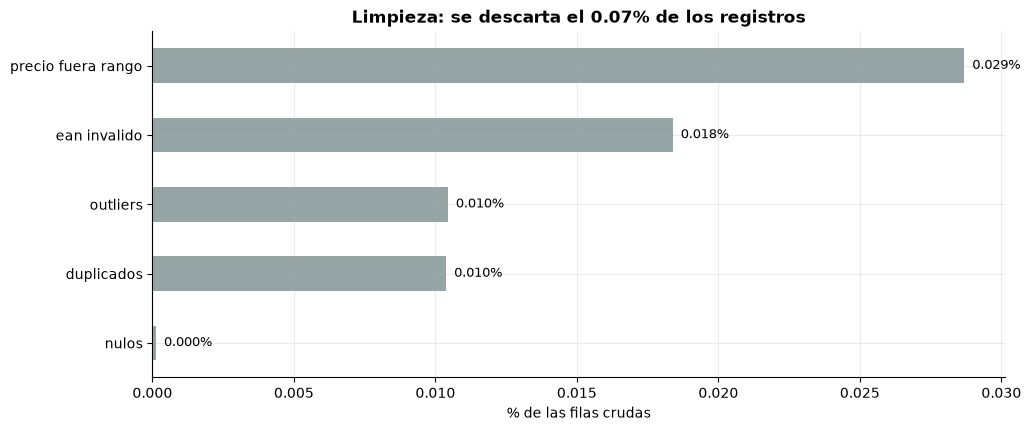

In [10]:
cal = pd.read_csv(cfg.INTERIM / "_calidad.csv")
display(cal)

desc = [c for c in cal.columns if c.startswith("desc_")]
pct = (100 * cal[desc].sum() / cal.filas_crudas.sum()).sort_values()
pct.index = [i.replace("desc_", "").replace("_", " ") for i in pct.index]
ax = pct.plot.barh(color="#95a5a6")
for i, v in enumerate(pct.values):
    ax.text(v, i, f"  {v:.3f}%", va="center", fontsize=9)
ax.set_xlabel("% de las filas crudas")
ax.set_title(f"Limpieza: se descarta el {pct.sum():.2f}% de los registros")
print(f"Filas crudas totales: {cal.filas_crudas.sum():,}")
print(f"Filas finales:        {cal.filas_finales.sum():,}")

> **Interpretación.** Un descarte muy bajo puede significar dos cosas opuestas:
> que el origen valida bien, o que mis reglas son demasiado permisivas y está
> entrando basura. Las secciones siguientes buscan basura que las reglas no ven.

## 2. El campo `productos_ean` no contiene el EAN

Uno de los hallazgos más caros del proyecto. El archivo de productos tiene una
columna llamada `productos_ean`, pero el código de barras está en `id_producto`.
`productos_ean` es la **cantidad** de EANs del producto, y vale 1 en casi todas
las filas.

```
12 | 1 | 170 | 7792180005205 | 1 | ACEITE OLIVA CAÑUELAS ... 
                ^ id_producto  ^ productos_ean (cantidad, no código)
```

Asumir lo contrario hizo que el pipeline descartara el **100%** de los registros
por "EAN inválido" y siguiera corriendo sin quejarse, escribiendo un parquet
vacío. De ahí salió el guardrail de `clean.py`: si una regla descarta más del
20% de las filas, el proceso corta y muestra ejemplos de lo que estaba tirando.

In [11]:
# Verificación sobre un archivo crudo: productos_ean es constante, id_producto no
import glob
crudos = sorted(glob.glob(str(cfg.RAW / dias[-1] / "**" / "productos.csv"), recursive=True))
if crudos:
    raw1 = pd.read_csv(crudos[0], sep="|", dtype=str, nrows=5000, on_bad_lines="skip")
    print("Archivo:", crudos[0].split("/")[-2], "\n")
    print("productos_ean -> valores distintos:", raw1.productos_ean.nunique(),
          "| ejemplos:", raw1.productos_ean.unique()[:5].tolist())
    print("id_producto   -> valores distintos:", raw1.id_producto.nunique(),
          "| ejemplos:", raw1.id_producto.unique()[:3].tolist())
else:
    print("No hay CSV crudos a mano (se borraron o cambió la ruta). El hallazgo está documentado arriba.")

Archivo: sepa_1_comercio-sepa-12_2026-07-25_09-05-11 

productos_ean -> valores distintos: 2 | ejemplos: ['0', '1']
id_producto   -> valores distintos: 824 | ejemplos: ['2046905000002', '2046906000001', '2000000452760']


## 3. Unidades de medida: dos vocabularios en la misma columna

`productos_unidad_medida_presentacion` mezcla **texto libre** (`gr`, `GR`, `grs`,
`LTS`, `cm3`) con **códigos UN/CEFACT Rec 20**, el estándar internacional
(`kgm` = kilogram, `ltr` = litre, `cmq` = centímetro cúbico, `ea` = each).

No hay ninguna marca que distinga unos de otros. Solo `ea` eran más de 1,4
millones de filas por día que se perdían como "unidad desconocida".

`src/unidades.py` mapea los dos vocabularios a tres unidades base: kg, litro y
unidad. Lo que mide longitud o superficie (`m`, `m2`, rollos de papel y film) se
deja fuera **a propósito**: no tiene equivalencia y forzarla sería inventar.

In [12]:
from src.unidades import unidades_no_reconocidas, _MAPA, NO_MAPEABLES

u = con.execute(f"""
    SELECT productos_unidad_medida_presentacion AS u, count(*) AS filas
    FROM read_parquet('{PARQUET}')
    WHERE u IS NOT NULL GROUP BY 1 ORDER BY filas DESC LIMIT 30
""").df()
u["mapeada"] = u.u.str.strip().str.lower().isin(_MAPA)
u["ignorada_a_proposito"] = u.u.str.strip().str.lower().isin(NO_MAPEABLES)
display(u)

sin_mapear = u[~u.mapeada & ~u.ignorada_a_proposito]
if len(sin_mapear):
    print("\nUnidades sin mapear ni ignorar — si alguna pesa, agregala a src/unidades.py:")
    display(sin_mapear)
else:
    print("\nTodas las unidades frecuentes están mapeadas o ignoradas explícitamente.")

,u,filas,mapeada,ignorada_a_proposito
0,UNI,23993607,True,False
1,GR,14651091,True,False
2,EA,10846313,True,False
3,ML,7231508,True,False
4,gr,6271782,True,False
5,KG,5831147,True,False
6,gr.,4708214,False,False
7,grm,3761870,True,False
8,cm3,3572142,True,False
9,UD,3169677,True,False



Unidades sin mapear ni ignorar — si alguna pesa, agregala a src/unidades.py:


,u,filas,mapeada,ignorada_a_proposito
6,gr.,4708214,False,False
10,ml.,2953662,False,False
16,un.,843218,False,False
21,pck,251656,False,False
22,cc.,246092,False,False
24,uni.,168911,False,False
26,lt.,133957,False,False


## 4. Dos fuentes del tamaño del envase que se contradicen

**Este es el hallazgo principal de calidad de datos del proyecto.**

Para saber el tamaño de un envase hay dos caminos:

| Fuente | Ejemplo |
|---|---|
| Columnas de presentación | `cantidad = 500`, `unidad = GR` |
| La descripción del producto | `"FIDEO GUISERO 500 GR"` |

Las columnas dedicadas son poco confiables: cerca del **39%** de los envases con
peso vienen declarados como `1 un`, y hay botellas de 900 ml informadas como
`1 gr` — lo que al dividir da precios de **$97 millones por litro**.

Por eso el pipeline usa la descripción como fuente principal, deja las columnas
como respaldo, y **mide la discrepancia** en vez de elegir una en silencio.

,fecha,pct_tamano_desc,pct_sin_tamano,pct_fuentes_discrepan
0,2026-07-19,44.74,1.05,21.83
1,2026-07-20,45.16,1.23,27.22
2,2026-07-21,46.05,1.25,27.41
3,2026-07-22,45.09,1.23,27.46
4,2026-07-23,44.03,1.06,22.02
5,2026-07-24,44.05,1.06,22.03
6,2026-07-25,44.43,1.07,22.63



Discrepancia entre fuentes: 21.8% a 27.5% (promedio 24.4%)
Que sea ESTABLE entre días es lo importante: no es un archivo roto,
es un problema sistemático de cómo se carga el dato en el origen.


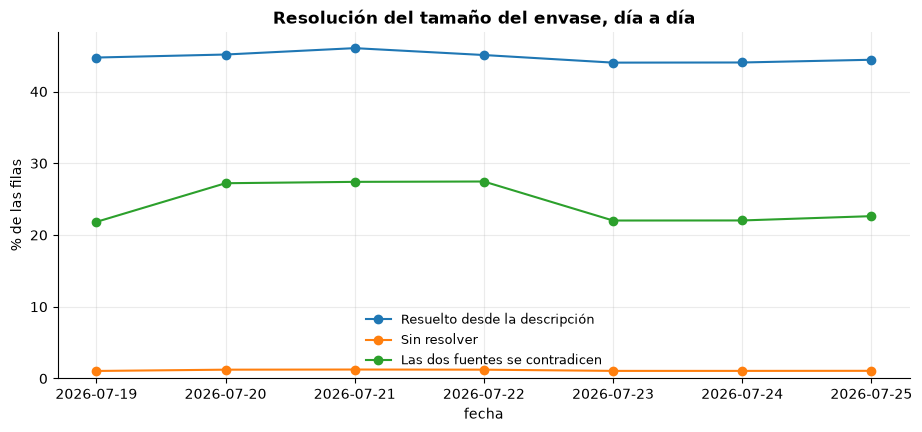

In [13]:
fuentes = cal[["fecha", "pct_tamano_desc", "pct_sin_tamano", "pct_fuentes_discrepan"]]
display(fuentes)

ax = fuentes.set_index("fecha").plot(marker="o")
ax.set_ylabel("% de las filas"); ax.set_ylim(0, None)
ax.set_title("Resolución del tamaño del envase, día a día")
ax.legend(["Resuelto desde la descripción", "Sin resolver",
           "Las dos fuentes se contradicen"], fontsize=9, frameon=False)

d = fuentes.pct_fuentes_discrepan
print(f"\nDiscrepancia entre fuentes: {d.min():.1f}% a {d.max():.1f}% (promedio {d.mean():.1f}%)")
print("Que sea ESTABLE entre días es lo importante: no es un archivo roto,")
print("es un problema sistemático de cómo se carga el dato en el origen.")

### Casos concretos de discrepancia

Nada convence más que ver las filas.

In [14]:
disc = con.execute(f"""
    SELECT descripcion, cantidad_base, unidad_base,
           productos_cantidad_presentacion AS cant_declarada,
           productos_unidad_medida_presentacion AS uni_declarada,
           round(precio, 0) AS precio, round(precio_unitario, 0) AS precio_x_unidad
    FROM read_parquet('{PARQUET}')
    WHERE fuente_tamano = 'descripcion'
      AND productos_cantidad_presentacion IS NOT NULL
      AND descripcion LIKE '%GR%'
      AND try_cast(productos_cantidad_presentacion AS DOUBLE) = 1
    USING SAMPLE 12 ROWS
""").df()
display(disc)
print("Envases con peso en la descripción, declarados como cantidad = 1 en las columnas.")

,descripcion,cantidad_base,unidad_base,cant_declarada,uni_declarada,precio,precio_x_unidad
0,NOODLES COREANO PICANTE G K POP KNORR X 67 GRS,0.067,kg,1,UNI,3876.0,57851.0
1,MAYONESA LIVIANA CADA DIA DOY PACK X 250 GRS,0.250,kg,1,UNI,799.0,3196.0


Envases con peso en la descripción, declarados como cantidad = 1 en las columnas.


## 5. Saltos de precio imposibles

Un salto de +200% de un día para el otro casi nunca es inflación: es un error de
carga o un cambio de presentación del producto con el mismo código.

In [15]:
salt = con.execute(f"""
    WITH d AS (
        SELECT fecha, cadena, ean, any_value(descripcion) AS descripcion,
               median(precio) AS p
        FROM read_parquet('{PARQUET}') GROUP BY 1,2,3
    ), v AS (
        SELECT *, lag(p) OVER (PARTITION BY cadena, ean ORDER BY fecha) AS p_prev FROM d
    )
    SELECT fecha, cadena, substr(descripcion,1,45) AS producto,
           round(p_prev,0) AS antes, round(p,0) AS despues,
           round(100.0*(p/nullif(p_prev,0)-1),0) AS var_pct
    FROM v
    WHERE p_prev IS NOT NULL AND abs(p/nullif(p_prev,0)-1) > 1.0
    ORDER BY abs(var_pct) DESC LIMIT 20
""").df()
display(salt)

total = con.execute(f"""
    WITH d AS (SELECT fecha, cadena, ean, median(precio) AS p
               FROM read_parquet('{PARQUET}') GROUP BY 1,2,3),
         v AS (SELECT *, lag(p) OVER (PARTITION BY cadena, ean ORDER BY fecha) AS pp FROM d)
    SELECT count(*) FILTER (WHERE abs(p/nullif(pp,0)-1) > 1.0) AS saltos,
           count(*) FILTER (WHERE pp IS NOT NULL) AS pares
    FROM v
""").df().iloc[0]
print(f"\nSaltos > 100% diario: {total.saltos:,} sobre {total.pares:,} pares ({100*total.saltos/total.pares:.3f}%)")

,fecha,cadena,producto,antes,despues,var_pct
0,2026-07-22,HIPERMERCADO LIBERTAD,LICOR WHISKY GLOUCESTER 750 CC,65.0,4494.0,6815.0
1,2026-07-22,HIPERMERCADO LIBERTAD,LICOR CAFE NS 750 CC,62.0,3619.0,5738.0
2,2026-07-23,SUPERCHANGOMAS,BONTUS DIBUJALO,7209.0,59999.0,732.0
3,2026-07-22,HIPERMERCADO LIBERTAD,GALLETAS PEPAS 9 DE ORO MEMBRI,225.0,1494.0,564.0
4,2026-07-23,SUPERCHANGOMAS,BONTUS UNA PISTA MAS,7209.0,39999.0,455.0
5,2026-07-22,HIPERMERCADO LIBERTAD,COPOS MAIZ AZUC.3 ARROY.X200G,217.0,1200.0,453.0
6,2026-07-22,HIPERMERCADO LIBERTAD,COPOS MAÍZ 3 ARROYOS AZUCARADO,461.0,2119.0,360.0
7,2026-07-22,HIPERMERCADO LIBERTAD,TURRON NAMUR GEORGALOS 25GR,69.0,238.0,245.0
8,2026-07-22,HIPERMERCADO LIBERTAD,GALLETAS 9 DE ORO VAINILLA CON,351.0,1120.0,219.0
9,2026-07-22,HIPERMERCADO LIBERTAD,GALLETAS 9 DE ORO VAINILLA CON,351.0,1120.0,219.0



Saltos > 100% diario: 27 sobre 771,004 pares (0.004%)


## 6. Cadenas y sucursales intermitentes

Si una sucursal reporta 3 de 7 días, el índice se mueve por composición de la
muestra y no por precios. Esta es la limitación más importante para cualquier
comparación temporal, y hay que declararla.

In [16]:
estab = con.execute(f"""
    WITH s AS (
        SELECT cadena, id_comercio, id_sucursal, count(DISTINCT fecha) AS dias
        FROM read_parquet('{PARQUET}') GROUP BY 1,2,3
    )
    SELECT dias, count(*) AS sucursales
    FROM s GROUP BY 1 ORDER BY dias
""").df()
display(estab)
completas = estab[estab.dias == len(dias)].sucursales.sum()
print(f"Sucursales presentes los {len(dias)} días: {completas:,} de {estab.sucursales.sum():,} "
      f"({100*completas/estab.sucursales.sum():.1f}%)")

cad = con.execute(f"""
    SELECT cadena, count(DISTINCT fecha) AS dias_reportados
    FROM read_parquet('{PARQUET}') GROUP BY 1 ORDER BY dias_reportados
""").df()
display(cad[cad.dias_reportados < len(dias)])

,dias,sucursales
0,1,3
1,2,1594
2,3,1035
3,4,5
4,6,73
5,7,1904


Sucursales presentes los 7 días: 1,904 de 4,614 (41.3%)


,cadena,dias_reportados
0,FULL,2
1,EXPRESS,2
2,MARKET,2
3,SIMPLICITY,3
4,HIPERMERCADO CARREFOUR,3
5,LA AGRICOLA REGIONAL COOPERATIVA LIMITADA,4
6,HIPERMERCADO LIBERTAD,6


## Conclusiones

### 1. La calidad del dato crudo es alta

Solo el **0,068%** de los 101,5 millones de registros se descarta por reglas de
calidad. SEPA valida bien en el origen: casi no hay precios imposibles, EANs rotos
ni duplicados.

Esto es importante decirlo, porque el resto de esta notebook muestra problemas
serios — y ninguno de ellos es de "datos sucios" en el sentido clásico.

### 2. El problema no son los valores, son los metadatos

Los tres hallazgos de fondo tienen la misma forma: **el dato está bien, lo que está
mal es cómo se describe.**

- Un campo llamado `productos_ean` que contiene la *cantidad* de EANs, no el EAN.
- Dos vocabularios de unidades mezclados en la misma columna sin distinción:
  texto libre (`gr`, `LTS`) y códigos UN/CEFACT (`kgm`, `cmq`, `ea`).
- Dos fuentes oficiales del tamaño del envase que se contradicen en el **24,4%**
  de los casos.

Ninguno de los tres lo detecta una regla de validación estándar. Los tres rompen
el análisis en silencio.

### 3. La discrepancia entre fuentes no es ruido, tiene estructura

| | Discrepancia |
|---|---|
| 19, 23, 24 y 25 de julio | 21,8% – 22,6% |
| 20, 21 y 22 de julio | 27,2% – 27,5% |

El salto de 5 puntos coincide con los días en que reportan **18 cadenas** en vez de
16. Es decir: la discrepancia no es aleatoria, **entra con cadenas específicas que
cargan peor el dato**. Identificar cuáles es el siguiente paso natural del análisis.

Gracias al mapeo de códigos UN/CEFACT, solo el **1,1%** de las filas queda sin
tamaño resoluble. El 44,8% se resuelve desde la descripción del producto y el resto
desde las columnas de presentación.

### 4. La muestra es mucho menos estable de lo que aparenta

Este es el hallazgo con más consecuencias, y el que más fácil se pasa por alto:

- Solo **1.904 de 4.614 sucursales (41,3%)** reportan los 7 días.
- **1.594 sucursales reportan solo 2 días** de los 7.
- Siete cadenas no reportan la serie completa, entre ellas las tres banderas del
  grupo Carrefour: **FULL, EXPRESS y MARKET reportan 2 días**, e **HIPERMERCADO
  CARREFOUR, 3**.

El conteo "16 a 18 cadenas por día" escondía esto: no es que se sumen dos cadenas
chicas, es que un grupo entero entra y sale.

**Consecuencia directa:** cualquier variación del índice entre fechas puede estar
reflejando composición de la muestra y no un cambio real de precios. Por eso el
proyecto reporta la dispersión *dentro de cada día* como hallazgo principal, y la
variación temporal solo como dato exploratorio.

## Limitaciones que se desprenden de esta notebook

1. **La muestra cambia día a día** (16 a 18 cadenas, y solo el 41,3% de las
   sucursales presentes los 7 días). Las comparaciones temporales están
   condicionadas por composición y no deben leerse como inflación.
2. **El 24,4% de los productos** tiene dos fuentes de tamaño que se contradicen.
   El pipeline prioriza la descripción, pero en ese cuarto de los casos la elección
   no es verificable.
3. **El 1,1% de las filas** no tiene tamaño resoluble y queda fuera del índice.
4. **El 25,7% de los EANs** aparece con más de una descripción, lo que limita
   cualquier estrategia de matcheo por código.
5. **Los precios son de lista**, sin promociones ni descuentos bancarios, que en
   Argentina mueven el precio efectivo más que la lista.
6. **SEPA cubre solo grandes superficies**: no hay almacenes de barrio, ferias ni
   mayoristas.